Understanding Embedding Models and Similarity 



In [20]:
!uv pip install rich pypdf2 matplotlib seaborn

Using Python 3.14.6 environment at: /Users/divyansh/Developer/AI-Ganga/.venv
Resolved 18 packages in 846ms                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/288.00 KiB          
⠙ Preparing packages... (0/1)------------------- 16.00 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)------------------- 32.00 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)------------------- 48.00 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)------------------- 60.80 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)------------------- 76.80 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)------------------- 92.80 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)------------------- 108.80 KiB/288.00 KiB       
⠙ Preparing packages... (0/1)m------------------ 124.80 KiB/288.00 KiB       
⠙ Preparing packages... (0/1)---------------- 140.80 KiB/288.00 KiB   

In [3]:
import re 
import os

from rich import print 
from sentence_transformers import SentenceTransformer
import numpy as np 
import textwrap
from IPython.display import display , HTML

In [7]:
# Load Data

from wikipediaapi import Wikipedia
wiki = Wikipedia('RAGBot/0.0' , 'en')
data = wiki.page('Rabbit').text

print(data)

Rabbits, or bunnies, are small mammals in the family Leporidae (which also includes the hares), which is in the 
order Lagomorpha (which also includes pikas). They are familiar throughout the world as a small herbivore, a prey 
animal, a domesticated form of livestock, and a pet, having a widespread effect on ecologies and cultures. The most
widespread rabbit genera are Oryctolagus and Sylvilagus. The former, Oryctolagus, includes the European rabbit, 
Oryctolagus cuniculus, which is the ancestor of the hundreds of breeds of domestic rabbit and has been introduced 
on every continent except Antarctica. The latter, Sylvilagus, includes over 13 wild rabbit species, among them the 
cottontails and tapetis. Wild rabbits not included in Oryctolagus and Sylvilagus include several species of limited
distribution, including the pygmy rabbit, volcano rabbit, and Sumatran striped rabbit.
Rabbits are a paraphyletic grouping, and do not constitute a clade, as hares (belonging to the genus Lepus) are 
nested within the Leporidae clade and are not described as rabbits. Although once considered rodents, lagomorphs 
diverged earlier and have a number of traits rodents lack, including two extra incisors. Similarities between 
rabbits and rodents were once attributed to convergent evolution, but studies in molecular biology have found a 
common ancestor between lagomorphs and rodents and place them in the clade Glires.
Rabbit physiology is suited to escaping predators and surviving in various habitats, living either alone or in 
groups in nests or burrows. As prey animals, rabbits are constantly aware of their surroundings, having a wide 
field of vision and ears with high surface area to detect potential predators. The ears of a rabbit are essential 
for thermoregulation and contain a high density of blood vessels. The bone structure of a rabbit's hind legs, which
is longer than that of the fore legs, allows for quick hopping, which is beneficial for escaping predators and can 
provide powerful kicks if captured. Rabbits are typically nocturnal and often sleep with their eyes open. They 
reproduce quickly, having short pregnancies, large litters of four to twelve kits, and no particular mating season;
however, the mortality rate of rabbit embryos is high, and there exist several widespread diseases that affect 
rabbits, such as rabbit hemorrhagic disease and myxomatosis. In some regions, especially Australia, rabbits have 
caused ecological problems and are regarded as a pest.
Humans have used rabbits as livestock since at least the first century BC in ancient Rome, raising them for their 
meat, fur and wool. The various breeds of the European rabbit have been developed to suit each of these products; 
the practice of raising and breeding rabbits as livestock is known as cuniculture. Rabbits are seen in human 
culture globally, appearing as a symbol of fertility, cunning, and innocence in major religions, historical and 
contemporary art.

Terminology and etymology
The word rabbit derives from the Middle English rabet ("young of the coney"), a borrowing from the Walloon robète, 
which was a diminutive of the French or Middle Dutch robbe ("rabbit"), a term of unknown origin. The term coney is 
a term for an adult rabbit used until the 18th century; rabbit once referred only to the young animals. More 
recently, the term kit or kitten has been used to refer to a young rabbit. The endearing word bunny is attested by 
the 1680s as a diminutive of bun, a term used in Scotland to refer to rabbits and squirrels.
Coney is derived from cuniculus, a Latin term referring to rabbits which has been in use from at least the first 
century BC in Hispania. The word cuniculus may originate from a diminutive form of the word for "dog" in the Celtic
languages.
A group of rabbits is known as a colony, nest, or warren, though the latter term more commonly refers to where the 
rabbits live. A group of baby rabbits produced from a single mating is referred to as a l

In [11]:
# performing chunking 

def chunk_text (text , chunk_size = 1000 , overlap = 20):
    """
    Split the text into chunks based on the number of words and word overlap
    """
    words = text.split()
    chunks = []

    for i in range (0,len(words) , chunk_size):
        chunk = ' '.join(words[i:i + chunk_size])
        chunks.append(chunk)
    return chunks
chunked_data = chunk_text(data)
print("Total Number of chunks" , len(chunked_data))


Total Number of chunks 7

In [13]:
def print_chunks(chunks):
    """
    Display text chunks in a clean, readable format using HTML styling.

    Args:
        chunks (list): List of text chunks to display
    """
    # Create the HTML for the chunks display
    html_content = """
    <style>
        .chunk-container {
            font-family: Arial, sans-serif;
            margin: 20px 0;
        }
        .chunk-header {
            background-color: #f0f2f6;
            padding: 5px 10px;
            border-radius: 5px 5px 0 0;
            border-left: 4px solid #3498db;
            font-weight: bold;
            color: #2c3e50;
        }
        .chunk-content {
            background-color: #ffffff;
            color: #2c3e50;
            padding: 10px;
            border: 1px solid #e1e4e8;
            border-left: 4px solid #3498db;
            border-top: none;
            border-radius: 0 0 5px 5px;
            white-space: pre-wrap;
            font-family: monospace;
        }
    </style>
    """

    # Add each chunk to the HTML content
    for i, chunk in enumerate(chunks, 1):
        # Wrap text for better readability
        wrapped_text = textwrap.fill(chunk, width=100)

        html_content += f"""
        <div class="chunk-container">
            <div class="chunk-header">Chunk {i}</div>
            <div class="chunk-content">{wrapped_text}</div>
        </div>
        """

    # Display the HTML
    display(HTML(html_content))
print_chunks(chunked_data)


In [ ]:
# setting up embedding model

model = SentenceTransformer("BAAI/bge-base-en-v1.5")

# set up cosine similarity function 


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10947.31it/s]


In [15]:
def cosine_similarity(vector_a, vector_b):
    """
    Calculate the cosine similarity between two vectors.
    Cosine similarity measures how similar two vectors are by calculating the cosine of the angle between them.

    Args:
        vector_a: First vector (numpy array)
        vector_b: Second vector (numpy array)

    Returns:
        float: Similarity score between -1 and 1
               1: Vectors are identical
               0: Vectors are perpendicular
              -1: Vectors are opposite
    """
    # Step 1: Calculate the dot product between the vectors
    # Dot product measures how much vectors point in the same direction
    dot_product = np.dot(vector_a, vector_b)

    # Step 2: Calculate the magnitude (length) of each vector
    # Magnitude is the square root of the sum of squared values
    magnitude_a = np.linalg.norm(vector_a)  # √(a1² + a2² + ... + an²)
    magnitude_b = np.linalg.norm(vector_b)  # √(b1² + b2² + ... + bn²)

    # Step 3: Calculate the cosine similarity
    # Divide dot product by the product of magnitudes
    similarity = dot_product / (magnitude_a * magnitude_b)

    return similarity


In [ ]:
# understanding similarity between two functions

## Change the sentences accordingly 
sentence1 = "The cat sat on the mat" 
sentence2 = "A cat is sitting on a mat"



In [17]:
def get_similarity_score(sentence1, sentence2):
    """
    Calculate similarity score between two sentences.

    Args:
        sentence1 (str): First sentence
        sentence2 (str): Second sentence

    Returns:
        float: Similarity score between 0 and 1
    """
    # Get embeddings
    embedding1 = model.encode(sentence1, normalize_embeddings=True)
    embedding2 = model.encode(sentence2, normalize_embeddings=True)

    # Calculate similarity
    similarity = cosine_similarity(embedding1, embedding2)

    return similarity

# change the sentences


score = get_similarity_score(sentence1, sentence2)
print(f"Similarity score: {score:.4f}")

Similarity score: 0.9566

Similarity Score: 0.9566

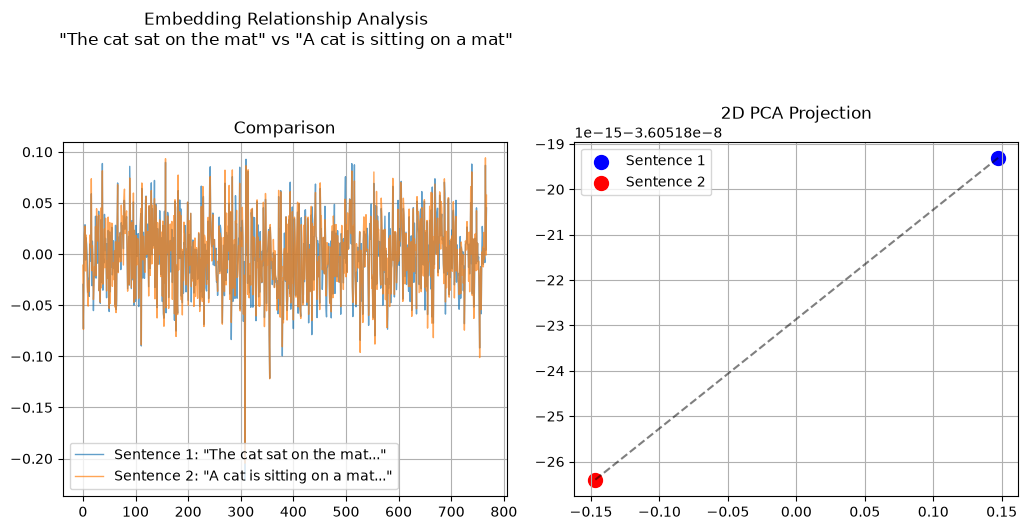

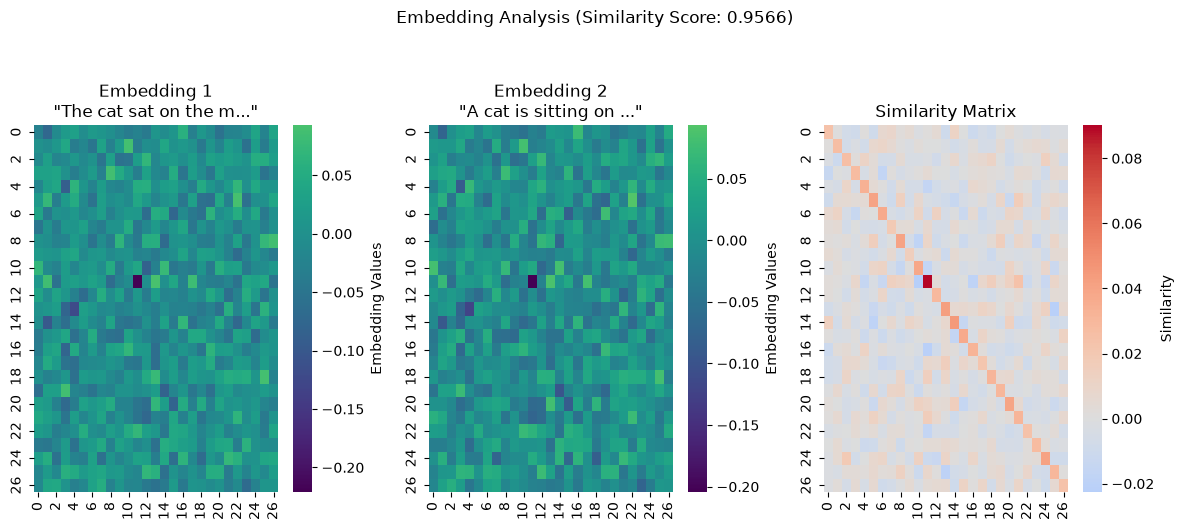

np.float32(0.95655775)

In [21]:
# visualize embeddings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def visualize_embeddings(sentence1, sentence2):
    """
    Visualize the relationship between two sentence embeddings using
    multiple visualization techniques.

    Args:
        sentence1 (str): First sentence
        sentence2 (str): Second sentence
    """
    # Get embeddings
    embedding1 = model.encode(sentence1, normalize_embeddings=True)
    embedding2 = model.encode(sentence2, normalize_embeddings=True)
    dimensions = range(len(embedding1))

    # Create figure with subplots
    fig = plt.figure(figsize=(15, 5))


    # Dimension-wise Comparison
    plt.subplot(132)
    plt.plot(dimensions, embedding1,
             label=f'Sentence 1: "{sentence1[:30]}..."',
             alpha=0.7,
             linewidth=1)
    plt.plot(dimensions, embedding2,
             label=f'Sentence 2: "{sentence2[:30]}..."',
             alpha=0.7,
             linewidth=1)
    plt.title('Comparison')
    plt.legend()
    plt.grid(True)

    # 2D PCA Projection
    plt.subplot(133)
    # Combine embeddings and apply PCA
    combined_embeddings = np.vstack([embedding1, embedding2])
    pca = PCA(n_components=2)
    projected = pca.fit_transform(combined_embeddings)

    plt.scatter(projected[0, 0], projected[0, 1], c='blue', label='Sentence 1', s=100)
    plt.scatter(projected[1, 0], projected[1, 1], c='red', label='Sentence 2', s=100)
    plt.plot([projected[0, 0], projected[1, 0]],
             [projected[0, 1], projected[1, 1]],
             'k--', alpha=0.5)
    plt.title('2D PCA Projection')
    plt.legend()
    plt.grid(True)

    # Add overall title and adjust layout
    plt.suptitle(f'Embedding Relationship Analysis\n"{sentence1}" vs "{sentence2}"',
                 fontsize=12, y=1.05)
    plt.tight_layout()

    # Calculate and display similarity score
    similarity = np.dot(embedding1, embedding2)
    print(f"Similarity Score: {similarity:.4f}")

    plt.show()

def plot_embedding_heatmap(sentence1, sentence2):
    """
    Create an improved heatmap visualization of embedding similarities.

    Args:
        sentence1 (str): First sentence
        sentence2 (str): Second sentence
    """
    # Get embeddings
    embedding1 = model.encode(sentence1, normalize_embeddings=True)
    embedding2 = model.encode(sentence2, normalize_embeddings=True)

    # Reshape embeddings to 2D matrices for better visualization
    size = int(np.sqrt(len(embedding1)))
    matrix1 = embedding1[:size*size].reshape(size, size)
    matrix2 = embedding2[:size*size].reshape(size, size)

    # Create similarity matrix
    similarity_matrix = np.dot(matrix1, matrix2.T)

    # Plot setup
    plt.figure(figsize=(12, 5))

    # Create subplots for both individual embeddings and their similarity
    plt.subplot(131)
    sns.heatmap(matrix1,
                cmap='viridis',
                center=0,
                cbar_kws={'label': 'Embedding Values'})
    plt.title(f'Embedding 1\n"{sentence1[:20]}..."')

    plt.subplot(132)
    sns.heatmap(matrix2,
                cmap='viridis',
                center=0,
                cbar_kws={'label': 'Embedding Values'})
    plt.title(f'Embedding 2\n"{sentence2[:20]}..."')

    plt.subplot(133)
    sns.heatmap(similarity_matrix,
                cmap='coolwarm',
                center=0,
                cbar_kws={'label': 'Similarity'})
    plt.title('Similarity Matrix')

    # Calculate overall similarity score
    similarity = np.dot(embedding1, embedding2)

    # Add overall title with similarity score
    plt.suptitle(f'Embedding Analysis (Similarity Score: {similarity:.4f})',
                 y=1.05)

    plt.tight_layout()
    plt.show()

    return similarity

visualize_embeddings(sentence1, sentence2)
plot_embedding_heatmap(sentence1, sentence2)


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]


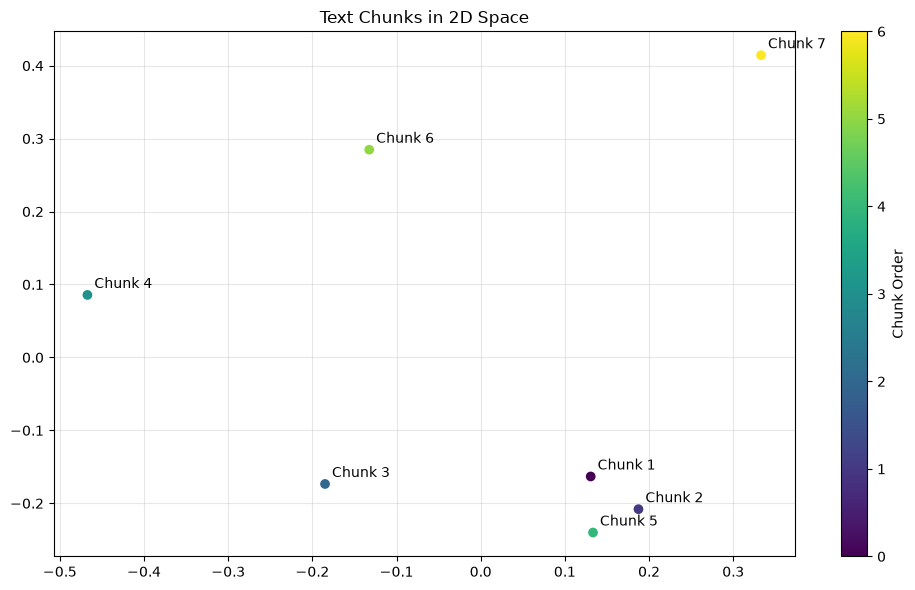

In [22]:
#embed chunks

def simple_visualize_chunks(chunks):
    """
    Create a simple 2D visualization of text chunk relationships.

    Args:
        chunks (list): List of text chunks to visualize
    """
    # Get embeddings and reduce dimensions
    embeddings = model.encode(chunks, normalize_embeddings=True, show_progress_bar=True)
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    # Create plot
    plt.figure(figsize=(10, 6))
    plt.scatter(reduced[:, 0], reduced[:, 1], c=range(len(chunks)), cmap='viridis')

    # Add labels
    for i, (x, y) in enumerate(reduced):
        plt.annotate(f"Chunk {i+1}", (x, y), xytext=(5, 5), textcoords='offset points')

    plt.title("Text Chunks in 2D Space")
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Chunk Order')

    plt.tight_layout()
    plt.show()

# Example usage:
# chunked_data = ["hello", "bird", "how are you doing" , "king"]
simple_visualize_chunks(chunked_data)

